# Benchmark on Synthetic CBN Data

Same pipeline as `benchmark_sachs.ipynb` but on synthetic data generated from a known continuous Bayesian network via `create_simple_cbn` + `generate_from_cbn`.

DAG structure (10 nodes, 12 arcs)

In [11]:
import sys
from pathlib import Path

import numpy as np
import seaborn as sns
import pyagrum as gum
import pyagrum.lib.notebook as gnb

sns.set_theme(style="whitegrid", palette="tab10", font_scale=1.1)

project_root = Path.cwd().parent
sys.path.insert(0, str(project_root))

from algorithms.CPCAdapter import CPCAdapter
from algorithms.CMIICAdapter import CMIICAdapter
from algorithms.MIICAdapter import MIICAdapter
from algorithms.GHCBDeuAdapter import GHCBDeuAdapter
from algorithms.NOTEARSAdapter import NOTEARSAdapter
from algorithms.LiNGAMAdapter import LiNGAMAdapter
from pipeline.Dataset import Dataset
from metrics.SHDMetric import SHDMetric
from metrics.F1ScoreMetric import F1ScoreMetric
from metrics.TPRMetric import TPRMetric
from data.generators import create_simple_cbn, generate_from_cbn
from notebooks.utils import (
    cpdag_to_dot, run_grid_searches, plot_grid_search_results,
    plot_summary_table, select_best_profiles, print_selection,
    plot_comparison_scatter, run_best_profiles, plot_cpdags,
    plot_pairwise_heatmaps,
)

## 1. Generation des donnees synthetiques

Dataset: 700 samples, 10 variables
Ground truth: 9 arcs, 3 edges

Golden CPDAG:


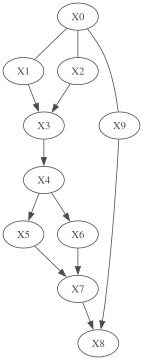

In [12]:
# Build DAG: 10 nodes, 12 arcs, 2 v-structures
dag = gum.DAG()
dag.addNodes(10)
arcs = [
    (0, 1), (0, 2), (0, 9),
    (1, 3), (2, 3),          # v-structure at 3
    (3, 4),
    (4, 5), (4, 6),
    (5, 7), (6, 7),          # v-structure at 7
    (7, 8), (9, 8),
]
for tail, head in arcs:
    dag.addArc(tail, head)

var_names = [f"X{i}" for i in range(10)]
cbn = create_simple_cbn(dag, var_names=var_names, copula_correlation=0.8)
dataset, ground_truth = generate_from_cbn(cbn, n_samples=700, seed=42)

dataset = Dataset(
    dataset.data,
    golden_structure=ground_truth,
    name="synthetic_10nodes",
    feature_names=var_names,
)

print(f"Dataset: {dataset.n_samples} samples, {dataset.n_features} variables")
print(f"Ground truth: {ground_truth.cpdag.sizeArcs()} arcs, {ground_truth.cpdag.sizeEdges()} edges")
print("\nGolden CPDAG:")
gnb.showDot(cpdag_to_dot(ground_truth, var_names))

## 2. Configuration

In [13]:
metrics = [SHDMetric(), F1ScoreMetric(), TPRMetric()]
metric_names = [m.name() for m in metrics]
objectives = {"SHD": True, "F1-Score": False, "TPR": False}
pareto_objectives = {"SHD": True, "F1-Score": False}

RANK_BY = "F1-Score"  # Pareto selection: choose which metric to prioritize "SHD" or "F1-Score"
VERBOSE = False # Verbosity: print grid search progress

grid_size = 20 # 20 dans le rapport
alphas_range = np.linspace(0.001, 0.5, grid_size)
nb_variables = 10
conditioning_sets_range = list(range(2, nb_variables - 2))
n_bins_range = list(range(2, 11))
hartemink_initial_bins_range = [10] # , 100, 1000]
notears_lambda1_range = np.linspace(0, 0.7, grid_size)
notears_threshold_range = np.linspace(0, 0.7, grid_size)
lingam_threshold_range = np.linspace(0, 1.2, grid_size)

algo_configs = [
    ("CPC v1",    CPCAdapter,      {"alpha": alphas_range, "max_conditioning_set_size": conditioning_sets_range}, {"version": 1}),
    ("CPC2 v2",   CPCAdapter,      {"alpha": alphas_range, "max_conditioning_set_size": conditioning_sets_range}, {"version": 2}),
    ("CMIIC v1",  CMIICAdapter,    {"alpha": alphas_range}, {"version": 1}),
    ("CMIIC2 v2", CMIICAdapter,    {"alpha": alphas_range}, {"version": 2}),
    ("MIIC",      MIICAdapter,     [
        {"n_bins": n_bins_range, "discretization_method": ["quantile"]},
        {"n_bins": n_bins_range, "discretization_method": ["hartemink"], "initial_bins": hartemink_initial_bins_range},
    ], {}),
    ("GHC+BDeu",  GHCBDeuAdapter,  [
        {"n_bins": n_bins_range, "discretization_method": ["quantile"]},
        {"n_bins": n_bins_range, "discretization_method": ["hartemink"], "initial_bins": hartemink_initial_bins_range},
    ], {}),
    ("NOTEARS",   NOTEARSAdapter,  {"lambda1": notears_lambda1_range, "w_threshold": notears_threshold_range}, {}),
    ("LiNGAM",    LiNGAMAdapter,   {"measure": ["pwling"], "threshold": lingam_threshold_range}, {}),
]

algo_configs_map = {name: (cls, fp) for name, cls, _, fp in algo_configs}

## 3. Grid search + visualisation par algorithme

Grid search:   0%|          | 0/736 [00:00<?, ?it/s]

Grid search: 100%|██████████| 736/736 [08:41<00:00,  1.41it/s, LiNGAM]   


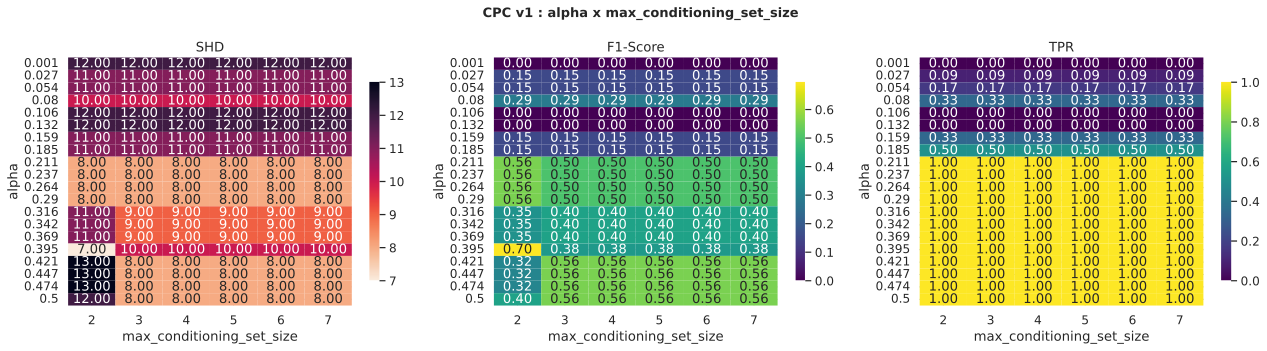

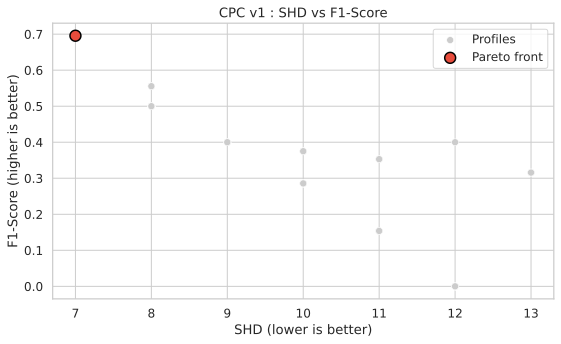

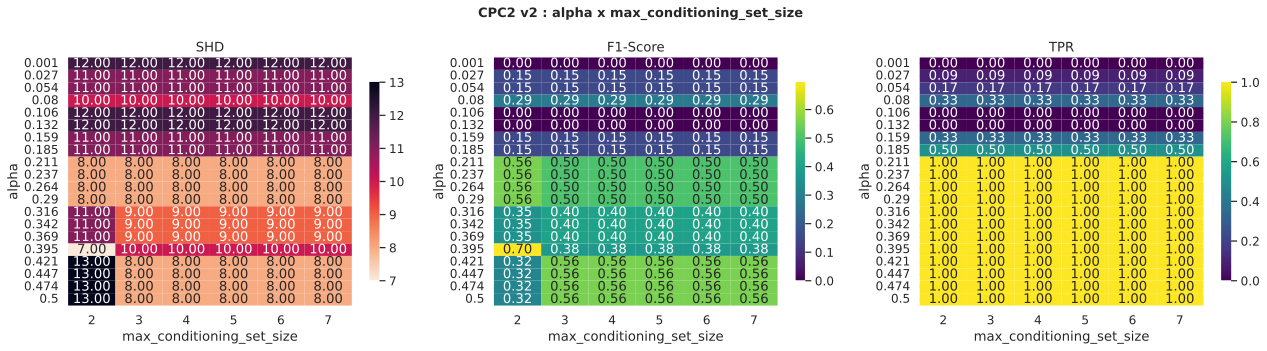

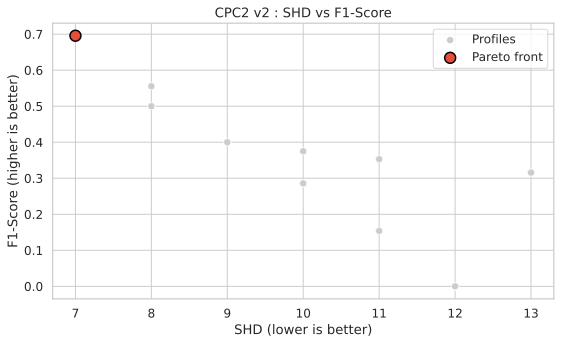

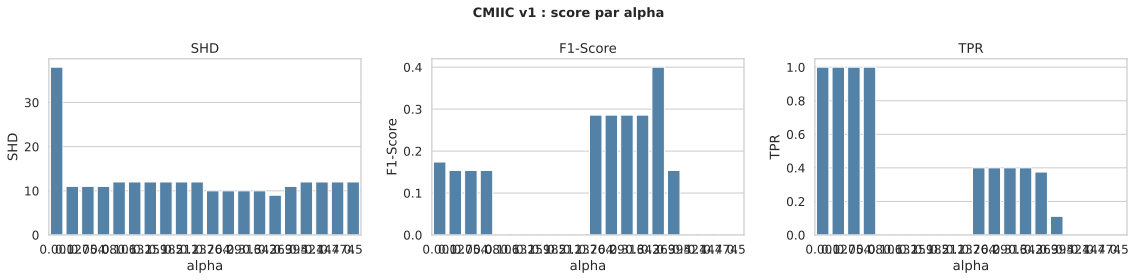

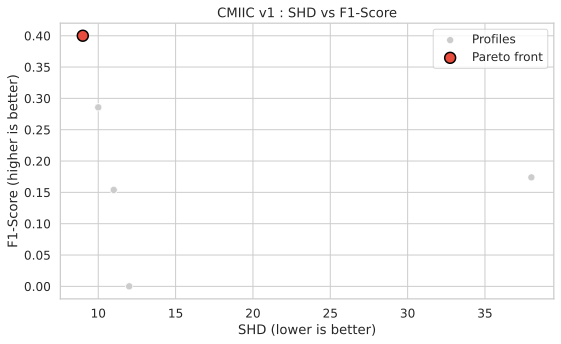

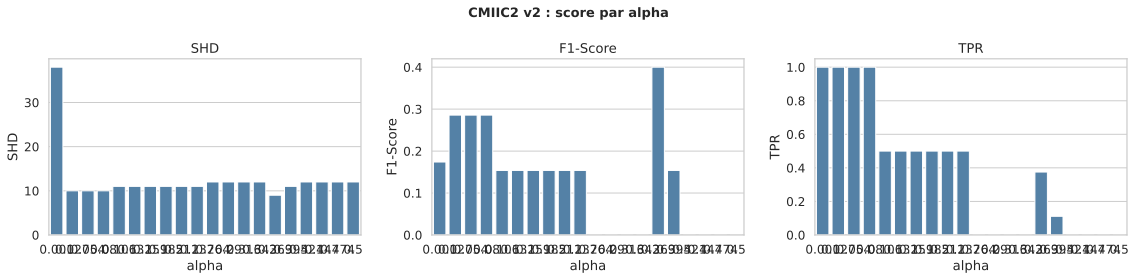

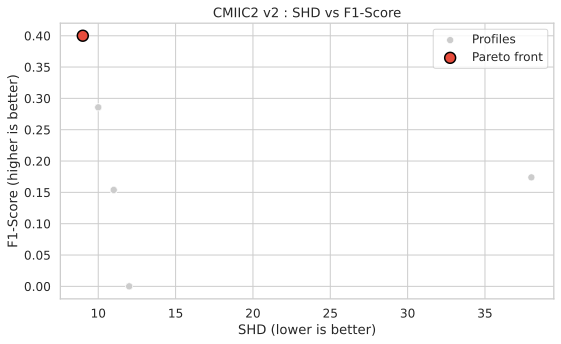

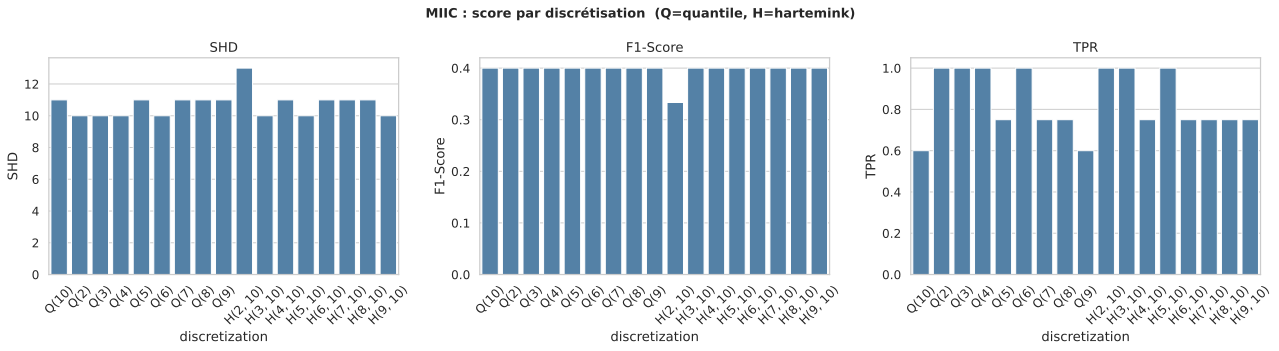

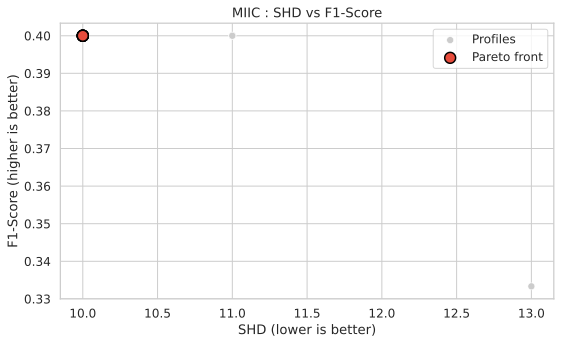

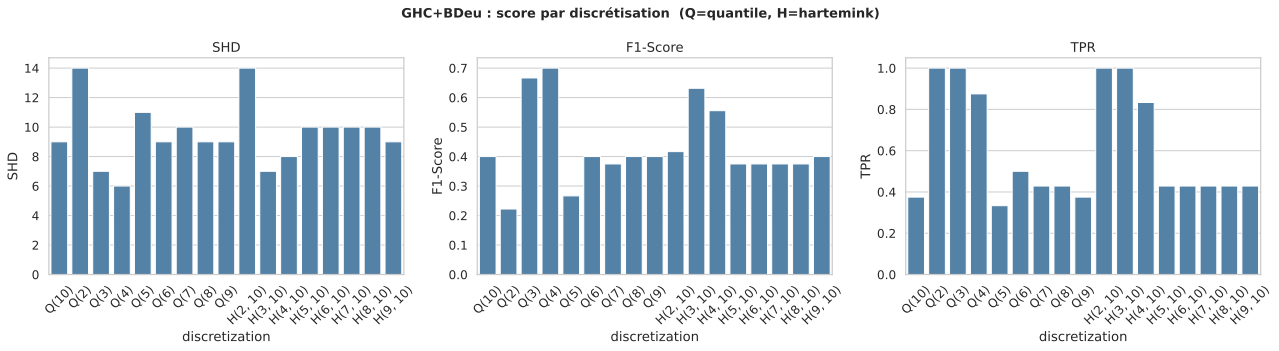

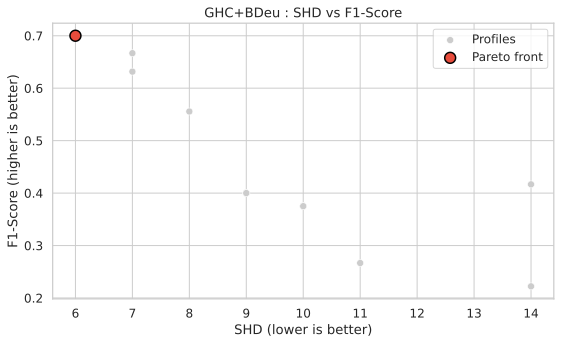

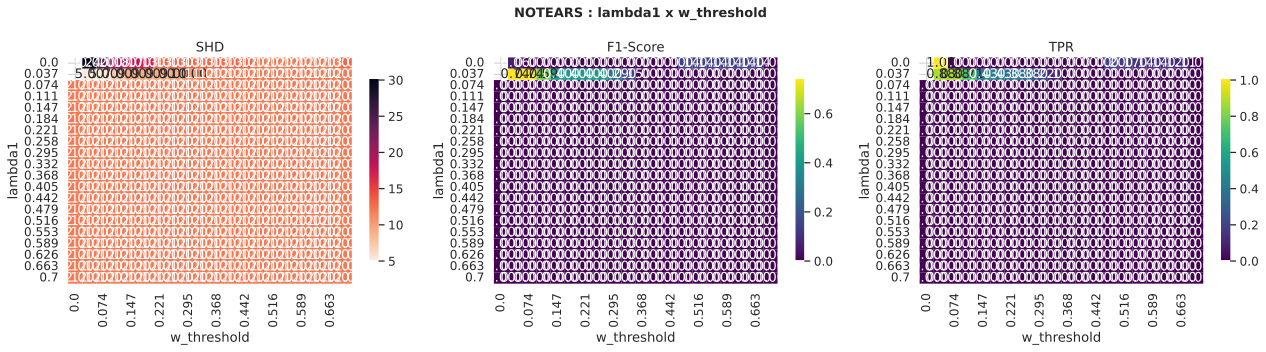

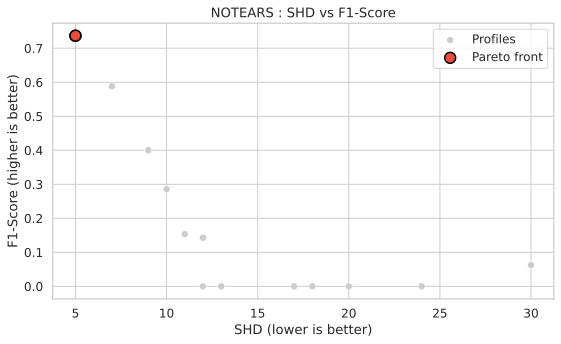

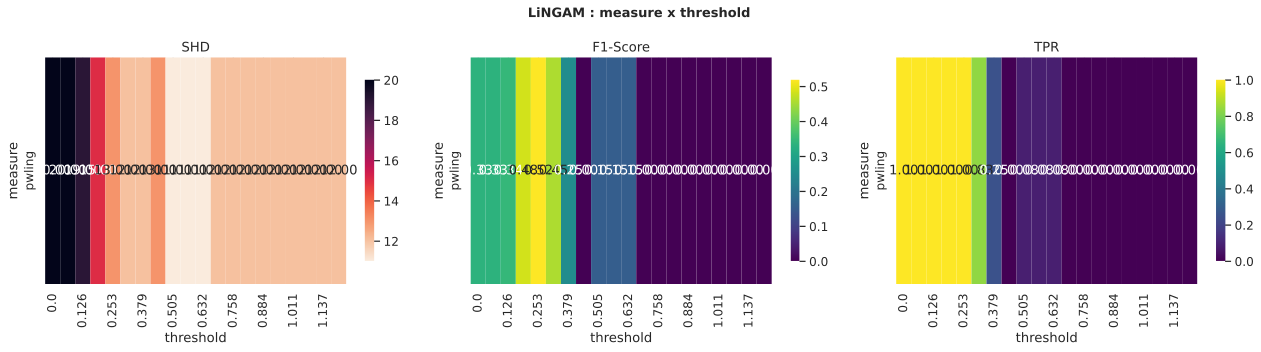

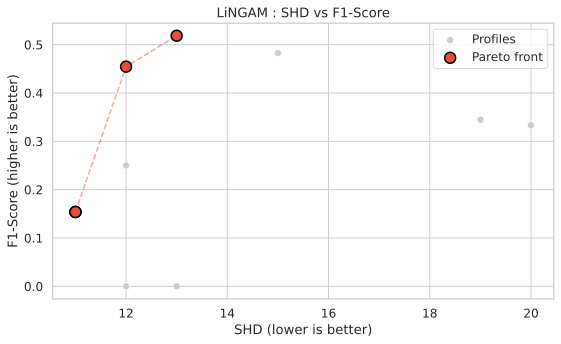

In [14]:
grid_searches = run_grid_searches(algo_configs, dataset, ground_truth, metrics, objectives, verbose=VERBOSE)

for name, algo_class, param_grid, fixed_params in algo_configs:
    plot_grid_search_results(name, grid_searches[name], param_grid, metric_names, pareto_objectives)

## 4. Tableau recapitulatif

In [15]:
plot_summary_table(grid_searches, metric_names)

,Best SHD,Best F1-Score,Best TPR
Algorithm,,,
CPC v1,7.0,0.695652,1.0
CPC2 v2,7.0,0.695652,1.0
CMIIC v1,9.0,0.400000,1.0
CMIIC2 v2,9.0,0.400000,1.0
MIIC,10.0,0.400000,1.0
GHC+BDeu,6.0,0.700000,1.0
NOTEARS,5.0,0.736842,1.0
LiNGAM,11.0,0.518519,1.0


## 5. Selection des meilleurs profils

Pour chaque algo, on selectionne le profil Pareto-optimal selon `RANK_BY` (defini dans la configuration).

In [16]:
selection = select_best_profiles(grid_searches, pareto_objectives, rank_by=RANK_BY)
print_selection(selection, RANK_BY)

Selection (Pareto max F1-Score):
  CPC v1          SHD=7.0    F1=0.696  params={'alpha': np.float64(0.395), 'max_conditioning_set_size': 2}
  CPC2 v2         SHD=7.0    F1=0.696  params={'alpha': np.float64(0.395), 'max_conditioning_set_size': 2}
  CMIIC v1        SHD=9.0    F1=0.400  params={'alpha': np.float64(0.369)}
  CMIIC2 v2       SHD=9.0    F1=0.400  params={'alpha': np.float64(0.369)}
  MIIC            SHD=10.0   F1=0.400  params={'n_bins': 2, 'discretization_method': 'quantile'}
  GHC+BDeu        SHD=6.0    F1=0.700  params={'n_bins': 4, 'discretization_method': 'quantile'}
  NOTEARS         SHD=5.0    F1=0.737  params={'lambda1': np.float64(0.037), 'w_threshold': np.float64(0.037)}
  LiNGAM          SHD=13.0   F1=0.519  params={'measure': 'pwling', 'threshold': np.float64(0.253)}


## 6. Scatter comparatif : tous les algos

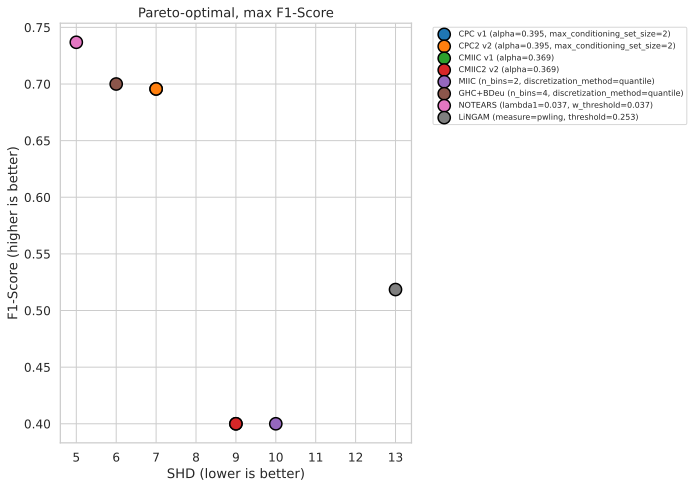

In [17]:
algo_names = list(grid_searches.keys())
plot_comparison_scatter(selection, algo_names, RANK_BY)

## 7. Structures apprises (CPDAGs)

Re-running best profiles...
Done.

Golden CPDAG (9 arcs, 3 edges):


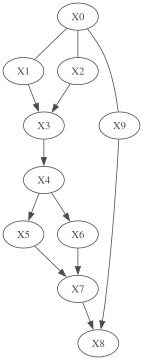

In [18]:
print("Re-running best profiles...")
structures = run_best_profiles(selection, algo_configs_map, dataset)
print("Done.\n")

print(f"Golden CPDAG ({ground_truth.cpdag.sizeArcs()} arcs, {ground_truth.cpdag.sizeEdges()} edges):")
gnb.showDot(cpdag_to_dot(ground_truth, var_names))


CPC v1 (alpha=0.395, max_conditioning_set_size=2) — 15 arcs, 0 edges


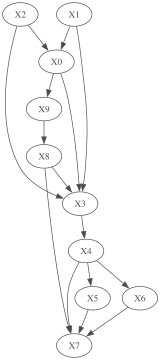


CPC2 v2 (alpha=0.395, max_conditioning_set_size=2) — 15 arcs, 0 edges


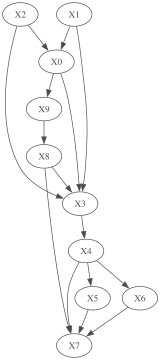


CMIIC v1 (alpha=0.369) — 0 arcs, 7 edges


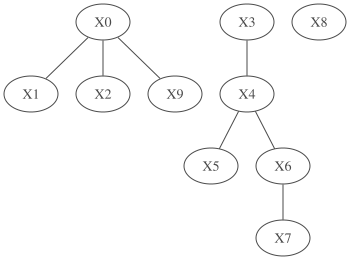


CMIIC2 v2 (alpha=0.369) — 0 arcs, 7 edges


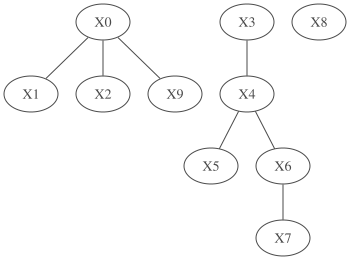


MIIC (n_bins=2, discretization_method=quantile) — 0 arcs, 12 edges


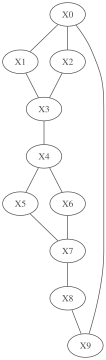


GHC+BDeu (n_bins=4, discretization_method=quantile) — 4 arcs, 8 edges


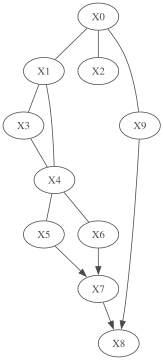


NOTEARS (lambda1=0.037, w_threshold=0.037) — 4 arcs, 7 edges


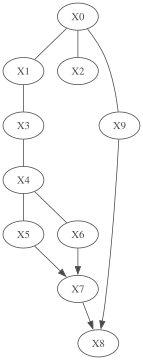


LiNGAM (measure=pwling, threshold=0.253) — 13 arcs, 7 edges


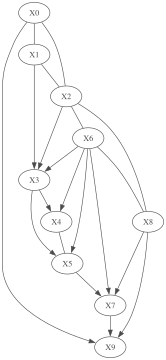

In [19]:
plot_cpdags(structures, selection, var_names)

## 8. Heatmaps pairwise

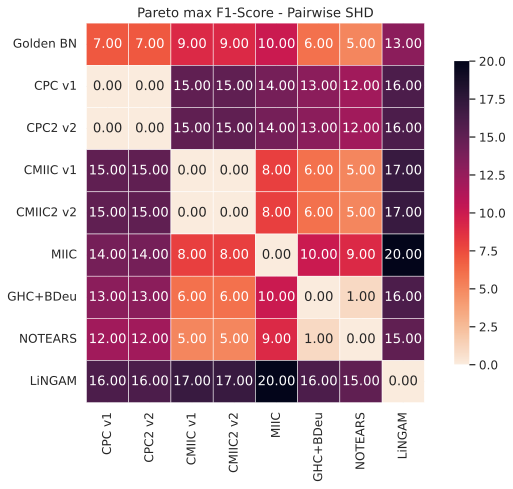

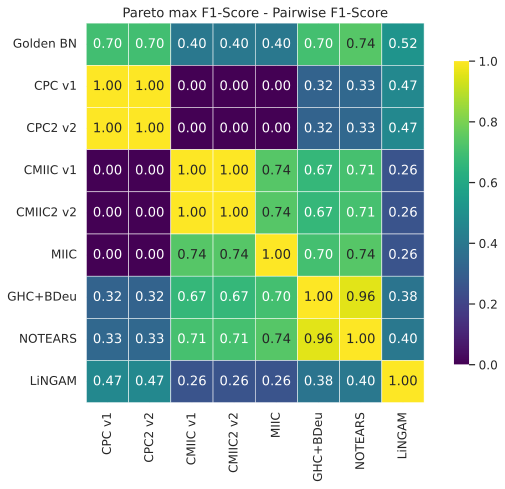

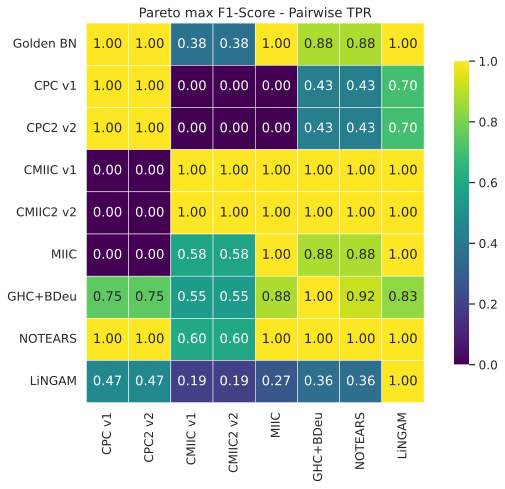

In [21]:
lower = "min" if RANK_BY == "SHD" else "max"
plot_pairwise_heatmaps(structures, f"Pareto {lower} {RANK_BY}", metrics, objectives, golden_structure=ground_truth)